# 02 — Descarga de Datasets Ambientales y de Rasgos

Este notebook descarga y preprocesa todos los datasets necesarios para el modelo:

| Dataset | Tipo | Destino |
|---------|------|---------|
| WorldClim v2.1 (bio1,4,7,12,14,15) | Raster climático | `data/worldclim/` |
| AVONET | Rasgos aves | `data/traits/` |
| PanTHERIA | Rasgos mamíferos | `data/traits/` |
| Global Forest Watch | Pérdida forestal | `data/gfw/` |
| MapBiomas Bolivia | Cobertura de suelo | `data/mapbiomas/` |
| Amazon Mining Watch | Minería ilegal | `data/mining/` |
| RAISG | Áreas protegidas | `data/raisg/` |

## 0. Setup

In [2]:
import requests
import zipfile
import io
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterio.crs import CRS
from shapely.geometry import box, mapping
from tqdm.notebook import tqdm

DATA = Path("../data")
TRAITS_DIR = DATA / "traits"
TRAITS_DIR.mkdir(parents=True, exist_ok=True)

# Bounding box de Bolivia (lon_min, lat_min, lon_max, lat_max)
BOLIVIA_BBOX = (-69.64, -22.90, -57.45, -9.67)
BOLIVIA_GEOM = [mapping(box(*BOLIVIA_BBOX))]

def download_file(url, dest_path, chunk_size=1024*1024):
    """Descarga un archivo con barra de progreso."""
    dest_path = Path(dest_path)
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    
    if dest_path.exists():
        print(f"  Ya existe: {dest_path.name} ({dest_path.stat().st_size / 1e6:.1f} MB)")
        return dest_path
    
    tmp_path = dest_path.with_suffix(".tmp")
    try:
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(tmp_path, 'wb') as f, tqdm(
                total=total, unit='B', unit_scale=True, desc=dest_path.name
            ) as bar:
                for chunk in r.iter_content(chunk_size=chunk_size):
                    f.write(chunk)
                    bar.update(len(chunk))
        tmp_path.rename(dest_path)
        print(f"  Descargado: {dest_path.name} ({dest_path.stat().st_size / 1e6:.1f} MB)")
    except Exception as e:
        if tmp_path.exists():
            tmp_path.unlink()
        raise RuntimeError(f"Error descargando {url}: {e}") from e
    return dest_path

def crop_raster_to_bolivia(src_path, dst_path):
    """Recorta un raster GeoTIFF al bbox de Bolivia usando gdalwarp (streaming, baja RAM)."""
    import subprocess
    dst_path = Path(dst_path)
    if dst_path.exists():
        print(f"  Ya existe: {dst_path.name}")
        return dst_path
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    lon_min, lat_min, lon_max, lat_max = BOLIVIA_BBOX
    subprocess.run([
        "gdalwarp",
        "-te", str(lon_min), str(lat_min), str(lon_max), str(lat_max),
        "-co", "COMPRESS=LZW",
        "-co", "TILED=YES",
        "-co", "BLOCKXSIZE=512",
        "-co", "BLOCKYSIZE=512",
        "-of", "GTiff",
        str(src_path), str(dst_path)
    ], check=True, capture_output=True)
    print(f"  Recortado: {dst_path.name} ({dst_path.stat().st_size / 1e6:.1f} MB)")
    return dst_path

print("Setup OK")

Setup OK


---
## 1. WorldClim v2.1 — Variables bioclimáticas

Variables seleccionadas:
- **bio1**: Temperatura media anual
- **bio4**: Estacionalidad de temperatura (CV)
- **bio7**: Rango anual de temperatura (bio5 - bio6)
- **bio12**: Precipitación anual
- **bio14**: Precipitación del mes más seco
- **bio15**: Estacionalidad de precipitación (CV)

Fuente: https://www.worldclim.org/data/worldclim21.html

In [3]:
WORLDCLIM_VARS = [1, 4, 7, 12, 14, 15]
# WorldClim solo distribuye ZIPs con las 19 variables juntas.
# Tamaños aproximados: 10m ~6 MB | 5m ~25 MB | 2.5m ~90 MB | 30s ~10 GB
WORLDCLIM_RES = "10"
WORLDCLIM_ZIP_URL = f"https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_{WORLDCLIM_RES}_bio.zip"
WORLDCLIM_DIR = DATA / "worldclim"
WORLDCLIM_DIR.mkdir(parents=True, exist_ok=True)
TMP_DIR = DATA / "_tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

missing = [n for n in WORLDCLIM_VARS if not (WORLDCLIM_DIR / f"bio{n}_bolivia.tif").exists()]

if missing:
    print(f"Variables faltantes: {missing}")
    zip_dest = TMP_DIR / f"wc2.1_{WORLDCLIM_RES}_bio.zip"
    extract_dir = TMP_DIR / f"wc2.1_{WORLDCLIM_RES}_bio"

    # Descargar ZIP si no existe
    if not zip_dest.exists():
        print(f"Descargando ZIP WorldClim {WORLDCLIM_RES}...")
        download_file(WORLDCLIM_ZIP_URL, zip_dest)

    # Extraer solo las variables que faltan
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_dest, 'r') as zf:
        all_names = zf.namelist()
        for bio_n in missing:
            # El nombre dentro del zip puede variar ligeramente
            candidates = [n for n in all_names if f"bio_{bio_n}." in n or f"bio_{bio_n:02d}." in n]
            if candidates:
                zf.extract(candidates[0], extract_dir)
                print(f"  Extraído: {candidates[0]}")
            else:
                print(f"  AVISO: bio_{bio_n} no encontrado. Contenido del ZIP: {all_names[:5]}...")

    # Recortar a Bolivia y limpiar
    for bio_n in missing:
        print(f"\n--- bio{bio_n} ---")
        tif_files = list(extract_dir.glob(f"**/*bio_{bio_n}.tif")) + list(extract_dir.glob(f"**/*bio_{bio_n:02d}.tif"))
        out_tif = WORLDCLIM_DIR / f"bio{bio_n}_bolivia.tif"
        if tif_files:
            crop_raster_to_bolivia(tif_files[0], out_tif)
        else:
            print(f"  ERROR: No se encontró TIF para bio{bio_n}")

    shutil.rmtree(extract_dir, ignore_errors=True)
    zip_dest.unlink(missing_ok=True)
    print("\nTemporales eliminados.")
else:
    print("Todos los archivos WorldClim ya existen.")

print("\nWorldClim completado.")
print("Archivos:", [f.name for f in WORLDCLIM_DIR.glob("*.tif")])

Todos los archivos WorldClim ya existen.

WorldClim completado.
Archivos: ['bio1_bolivia.tif', 'bio4_bolivia.tif', 'bio7_bolivia.tif', 'bio12_bolivia.tif', 'bio14_bolivia.tif', 'bio15_bolivia.tif']


### Verificación WorldClim

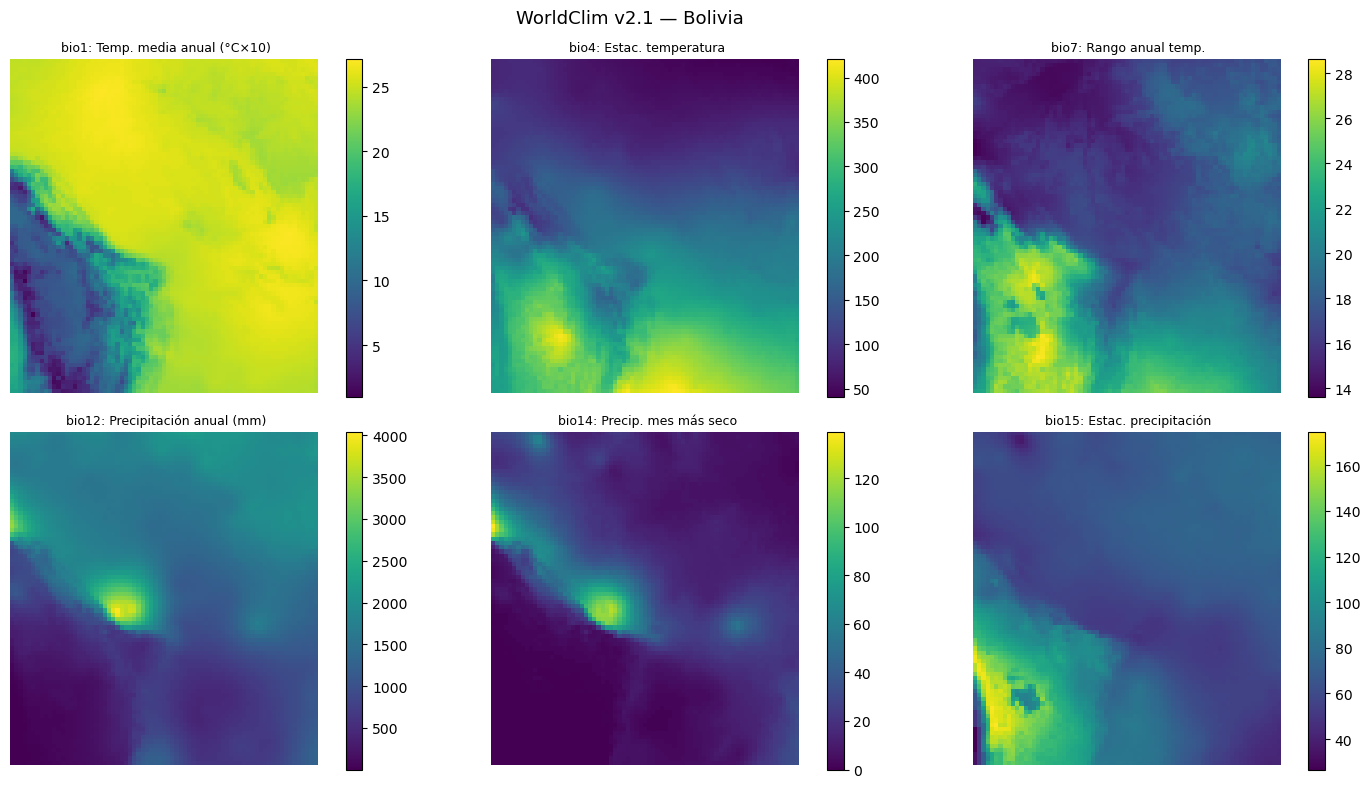

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
titles = {1: 'bio1: Temp. media anual (°C×10)', 4: 'bio4: Estac. temperatura',
          7: 'bio7: Rango anual temp.', 12: 'bio12: Precipitación anual (mm)',
          14: 'bio14: Precip. mes más seco', 15: 'bio15: Estac. precipitación'}

for ax, bio_n in zip(axes.flat, WORLDCLIM_VARS):
    tif = WORLDCLIM_DIR / f"bio{bio_n}_bolivia.tif"
    with rasterio.open(tif) as src:
        data = src.read(1).astype(float)
        data[data == src.nodata] = np.nan
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(titles[bio_n], fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('WorldClim v2.1 — Bolivia', fontsize=13)
plt.tight_layout()
plt.savefig(DATA / "worldclim" / "worldclim_preview.png", dpi=100)
plt.show()

---
## 2. AVONET — Rasgos biológicos de aves

Tobias et al. 2022 — AVONET: morphological, ecological and geographical data for all birds.  
Publicado en *Ecology Letters* 25(3), 581–597.  
Fuente: https://figshare.com/articles/dataset/AVONET_supplementary_dataset1_BirdLife/16586228

In [5]:
avonet_path = TRAITS_DIR / "AVONET.xlsx"
avonet_url = "https://ndownloader.figshare.com/files/34480856"

if not avonet_path.exists():
    tmp_path = TRAITS_DIR / "avonet_download.tmp"
    download_file(avonet_url, tmp_path)
    tmp_path.rename(avonet_path)
    print(f"  Guardado: {avonet_path.name}")
else:
    print(f"  Ya existe: {avonet_path.name}")

avonet = pd.read_excel(avonet_path, sheet_name="AVONET1_BirdLife", engine="openpyxl")
print(f"\nAVONET: {avonet.shape[0]:,} especies, {avonet.shape[1]} columnas")
print(avonet.columns.tolist())

  Ya existe: AVONET.xlsx

AVONET: 11,009 especies, 37 columnas
['Sequence', 'Species1', 'Family1', 'Order1', 'Avibase.ID1', 'Total.individuals', 'Female', 'Male', 'Unknown', 'Complete.measures', 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Hand-Wing.Index', 'Tail.Length', 'Mass', 'Mass.Source', 'Mass.Refs.Other', 'Inference', 'Traits.inferred', 'Reference.species', 'Habitat', 'Habitat.Density', 'Migration', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle', 'Min.Latitude', 'Max.Latitude', 'Centroid.Latitude', 'Centroid.Longitude', 'Range.Size']


In [6]:
# Fix rápido: el .tmp ya está descargado, solo renombrarlo
from pathlib import Path
tmp = Path("../data/traits/avonet_download.tmp")
dst = Path("../data/traits/AVONET.xlsx")
if tmp.exists() and not dst.exists():
    tmp.rename(dst)
    print("Renombrado OK")
elif dst.exists():
    print("Ya existe AVONET.xlsx")
else:
    print("No se encontró el .tmp")

Ya existe AVONET.xlsx


In [7]:
# Columnas relevantes para el modelo
AVONET_COLS = [
    'Species1',
    'Beak.Length_Culmen', 'Beak.Width', 'Beak.Depth',
    'Tarsus.Length', 'Wing.Length', 'Kipps.Distance',
    'Mass',
    'Habitat', 'Habitat.Density',
    'Migration',
    'Trophic.Level', 'Trophic.Niche',
    'Primary.Lifestyle',
    'Range.Size'
]

# Filtrar solo columnas que existen
available_cols = [c for c in AVONET_COLS if c in avonet.columns]
avonet_slim = avonet[available_cols].copy()
avonet_slim.to_csv(TRAITS_DIR / "avonet_slim.csv", index=False)

print(f"Columnas seleccionadas: {len(available_cols)}")
print(avonet_slim.head(3).to_string())

Columnas seleccionadas: 15
                Species1  Beak.Length_Culmen  Beak.Width  Beak.Depth  Tarsus.Length  Wing.Length  Kipps.Distance    Mass    Habitat  Habitat.Density  Migration Trophic.Level Trophic.Niche Primary.Lifestyle   Range.Size
0  Accipiter albogularis                27.7        10.6        14.7           62.0        235.2            81.8  248.75     Forest                1        2.0     Carnivore     Vertivore       Insessorial     37461.21
1       Accipiter badius                20.6         8.8        11.6           43.0        186.7            62.5  131.15  Shrubland                2        3.0     Carnivore     Vertivore       Insessorial  22374973.00
2      Accipiter bicolor                25.0         8.6        12.7           58.1        229.6            56.6  287.54   Woodland                2        2.0     Carnivore     Vertivore        Generalist  14309701.27


---
## 3. PanTHERIA — Rasgos biológicos de mamíferos

Jones et al. 2009 — PanTHERIA: a species-level database of life history, ecology, and geography of extant and recently extinct mammals.  
Fuente: ESA Data Archive (esapubs.org)


In [8]:
pantheria_path = TRAITS_DIR / "PanTHERIA.txt"
pantheria_url = "https://esapubs.org/archive/ecol/E090/184/PanTHERIA_1-0_WR05_Aug2008.txt"

download_file(pantheria_url, pantheria_path)

# Leer y verificar
pantheria = pd.read_csv(pantheria_path, sep="\t", low_memory=False)
print(f"\nPanTHERIA: {pantheria.shape[0]:,} especies, {pantheria.shape[1]} columnas")
print("\nPrimeras columnas:")
print(pantheria.columns[:15].tolist())

  Ya existe: PanTHERIA.txt (2.4 MB)

PanTHERIA: 5,416 especies, 55 columnas

Primeras columnas:
['MSW05_Order', 'MSW05_Family', 'MSW05_Genus', 'MSW05_Species', 'MSW05_Binomial', '1-1_ActivityCycle', '5-1_AdultBodyMass_g', '8-1_AdultForearmLen_mm', '13-1_AdultHeadBodyLen_mm', '2-1_AgeatEyeOpening_d', '3-1_AgeatFirstBirth_d', '18-1_BasalMetRate_mLO2hr', '5-2_BasalMetRateMass_g', '6-1_DietBreadth', '7-1_DispersalAge_d']


In [9]:
# Columnas relevantes para el modelo
PANTHERIA_COLS = [
    'MSW05_Binomial',
    '5-1_AdultBodyMass_g',
    '9-1_GestationLen_d',
    '14-1_InterbirthInterval_d',
    '15-1_LitterSize',
    '17-1_MaxLongevity_m',
    '23-1_SexualMaturityAge_d',
    '22-1_SexRatio_MtoF',
    '24-1_TeatNumber',
    '25-1_WeaningAge_d',
    '6-1_DietBreadth',
    '6-2_TrophicLevel',
    '1-1_ActivityCycle',
    '26-1_GR_Area_km2',
    '22-2_HomeRange_km2',
    '21-1_PopulationDensity_n/km2'
]

# Filtrar solo columnas que existen
available_cols = [c for c in PANTHERIA_COLS if c in pantheria.columns]
pantheria_slim = pantheria[available_cols].copy()
pantheria_slim.to_csv(TRAITS_DIR / "pantheria_slim.csv", index=False)

print(f"Columnas seleccionadas: {len(available_cols)}")
print(f"Especies: {pantheria_slim.shape[0]:,}")
print(pantheria_slim.head(3).to_string())

Columnas seleccionadas: 14
Especies: 5,416
        MSW05_Binomial  5-1_AdultBodyMass_g  9-1_GestationLen_d  14-1_InterbirthInterval_d  15-1_LitterSize  17-1_MaxLongevity_m  23-1_SexualMaturityAge_d  24-1_TeatNumber  25-1_WeaningAge_d  6-1_DietBreadth  6-2_TrophicLevel  1-1_ActivityCycle  26-1_GR_Area_km2  21-1_PopulationDensity_n/km2
0  Camelus dromedarius            492714.47              386.51                     614.41             0.98                480.0                   1947.94             -999             389.38              3.0                 1                3.0           -999.00                          0.98
1        Canis adustus             10392.49               65.00                    -999.00             4.50                137.0                    249.88                8              52.89              6.0                 2                1.0       10581413.14                          0.74
2         Canis aureus              9658.70               61.24               

---
## 4. Global Forest Watch — Pérdida de cobertura forestal

Hansen et al. 2023 (GFC v1.11) — High-Resolution Global Maps of 21st-Century Forest Cover Change.  
Capa: `lossyear` — año de pérdida de cobertura forestal (1=2001, 23=2023)  
Fuente: https://www.globalforestwatch.org/

Tiles que cubren Bolivia (bbox: -69.64 a -57.45 lon, -22.90 a -9.67 lat):
- `00N_070W` → cobre norte de Bolivia
- `10S_070W` → cubre centro-norte
- `10S_060W` → cubre noreste
- `20S_070W` → cubre sur-oeste
- `20S_060W` → cubre sur-este
- `20S_050W` → cubre extremo este

In [10]:
GFW_DIR = DATA / "gfw"
GFW_DIR.mkdir(parents=True, exist_ok=True)
GFW_BASE = "https://storage.googleapis.com/earthenginepartners-hansen/GFC-2023-v1.11"

# Tiles que cubren Bolivia
GFW_TILES = ["00N_070W", "10S_070W", "10S_060W", "20S_070W", "20S_060W", "20S_050W"]

tile_paths = []
for tile in GFW_TILES:
    print(f"\n--- Tile {tile} ---")
    url = f"{GFW_BASE}/Hansen_GFC-2023-v1.11_lossyear_{tile}.tif"
    dest = TMP_DIR / f"gfw_lossyear_{tile}.tif"
    try:
        download_file(url, dest)
        tile_paths.append(dest)
    except Exception as e:
        print(f"  AVISO: No se pudo descargar tile {tile}: {e}")

print(f"\nTiles descargados: {len(tile_paths)} de {len(GFW_TILES)}")


--- Tile 00N_070W ---


gfw_lossyear_00N_070W.tif:   0%|          | 0.00/51.3M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
# Mosaico y recorte a Bolivia
import subprocess

gfw_out = GFW_DIR / "lossyear_bolivia.tif"

if not gfw_out.exists() and tile_paths:
    print("Creando mosaico (VRT, sin cargar RAM)...")

    # VRT: índice virtual, no carga datos a memoria
    vrt_path = TMP_DIR / "gfw_mosaic.vrt"
    subprocess.run(
        ["gdalbuildvrt", str(vrt_path)] + [str(p) for p in tile_paths],
        check=True, capture_output=True
    )

    # Recortar a Bolivia directo desde el VRT (streaming)
    crop_raster_to_bolivia(vrt_path, gfw_out)

    vrt_path.unlink(missing_ok=True)
    for p in tile_paths:
        p.unlink(missing_ok=True)
    print(f"GFW lossyear Bolivia: {gfw_out.stat().st_size / 1e6:.1f} MB")
elif gfw_out.exists():
    print(f"Ya existe: {gfw_out.name}")
else:
    print("ERROR: No hay tiles disponibles para crear el mosaico.")

Creando mosaico...


KeyboardInterrupt: 

---
## 5. MapBiomas Bolivia — Cobertura de suelo

MapBiomas — clasificación anual de cobertura y uso del suelo.  
Colección Chaco v3 y Amazonía v9, integradas para Bolivia.

> **Nota:** MapBiomas no ofrece URLs directas estables para descarga programática en todas sus colecciones. Se prueban las URLs públicas conocidas; si fallan, se incluyen instrucciones de descarga manual vía GEE o el portal de MapBiomas.

In [ ]:
MAPBIOMAS_DIR = DATA / "mapbiomas"
MAPBIOMAS_DIR.mkdir(parents=True, exist_ok=True)

# Intentar URLs públicas de MapBiomas (GCS)
MAPBIOMAS_URLS = [
    # Colección Chaco - integración
    "https://storage.googleapis.com/mapbiomas-public/initiatives/chaco/collection_3/integration/coverage/coverage_chaco_collection3_integration_v1.tif",
    # Alternativa: Amazon colección 9
    "https://storage.googleapis.com/mapbiomas-public/brasil/collection-9/lclu-classification/mapbiomas-brazil-collection-9-amazonia-2023.tif",
]

mapbiomas_global = TMP_DIR / "mapbiomas_source.tif"
mapbiomas_out = MAPBIOMAS_DIR / "mapbiomas_bolivia_2023.tif"

downloaded = False
if not mapbiomas_out.exists():
    for url in MAPBIOMAS_URLS:
        try:
            print(f"Intentando: {url[:60]}...")
            download_file(url, mapbiomas_global)
            crop_raster_to_bolivia(mapbiomas_global, mapbiomas_out)
            mapbiomas_global.unlink(missing_ok=True)
            downloaded = True
            break
        except Exception as e:
            print(f"  Falló: {e}")
            mapbiomas_global.unlink(missing_ok=True)
    
    if not downloaded:
        print("""
⚠️  DESCARGA MANUAL REQUERIDA — MapBiomas Bolivia

Las URLs automáticas no están disponibles. Opciones:

1. Portal MapBiomas:
   https://plataforma.brasil.mapbiomas.org/
   → Descargar → Bolivia → Guardar en data/mapbiomas/mapbiomas_bolivia_2023.tif

2. Google Earth Engine (requiere cuenta GEE):
   asset: 'projects/mapbiomas-chaco/public/collection3/mapbiomas_chaco_collection3_classification_v1'
   → Exportar región Bolivia al GCS o Drive

3. MapBiomas STAC API:
   https://stac.mapbiomas.org/
""")
else:
    print(f"Ya existe: {mapbiomas_out.name}")

---
## 6. Amazon Mining Watch — Minería ilegal

Datos de actividad minera ilegal en la Amazonía.  
Fuentes: RAISG / MAAP (Monitoring of the Andean Amazon Project) / Global Mining Watch

Intentamos múltiples fuentes en orden de preferencia.

In [11]:
MINING_DIR = DATA / "mining"
MINING_DIR.mkdir(parents=True, exist_ok=True)
mining_out = MINING_DIR / "mining_bolivia.geojson"

# Fuente 1: RAISG - Minería ilegal en Amazonía (GeoJSON público)
MINING_URLS = [
    # Earthrise Media - Mining Detector (modelo ML, Amazon Basin, ensemble 2023) ← mejor fuente
    "https://raw.githubusercontent.com/earthrise-media/mining-detector/main/data/outputs/48px_v3.7a-i_ensemble/amazon_basin_48px_v3.7-ensemble_0.50_2023-01-01_2023-12-31-dissolved-0.6.geojson",
    # RAISG Amazonia - minería ilegal
    "https://amazoniasocioambiental.org/wp-content/uploads/2023/09/Mineria_ilegal_Amazonia.zip",
    # Global Mining Watch (dataset académico open)
    "https://raw.githubusercontent.com/Global-Witness/mining-watch/main/data/mining_areas.geojson",
    # S2Glob - Global Surface Mining (Landsat-based)
    "https://zenodo.org/record/7244167/files/global_surface_mining.geojson",
]

if not mining_out.exists():
    bolivia_gdf = gpd.GeoDataFrame(geometry=[box(*BOLIVIA_BBOX)], crs="EPSG:4326")
    
    for url in MINING_URLS:
        try:
            print(f"Intentando: {url[:60]}...")
            tmp = TMP_DIR / "mining_source"
            
            if url.endswith(".zip"):
                r = requests.get(url, timeout=60)
                r.raise_for_status()
                z = zipfile.ZipFile(io.BytesIO(r.content))
                z.extractall(TMP_DIR / "mining_zip")
                shp_files = list((TMP_DIR / "mining_zip").glob("**/*.shp"))
                if not shp_files:
                    raise ValueError("No se encontró .shp en el zip")
                gdf = gpd.read_file(shp_files[0])
            else:
                gdf = gpd.read_file(url)
            
            if gdf.crs is None:
                gdf = gdf.set_crs("EPSG:4326")
            elif gdf.crs != CRS.from_epsg(4326):
                gdf = gdf.to_crs("EPSG:4326")
            
            # Clip a Bolivia
            gdf_bolivia = gpd.clip(gdf, bolivia_gdf)
            
            if len(gdf_bolivia) == 0:
                print(f"  AVISO: Sin features en Bolivia para esta fuente")
                continue
            
            gdf_bolivia.to_file(mining_out, driver="GeoJSON")
            print(f"  Guardado: {len(gdf_bolivia)} polígonos de minería en Bolivia")
            break
        except Exception as e:
            print(f"  Falló: {e}")
    else:
        print("""
⚠️  DESCARGA MANUAL REQUERIDA — Mining Watch Bolivia

Opciones:
1. RAISG Amazonia: https://amazoniasocioambiental.org/mapa/#
   → Descargar capa de Minería Ilegal → Guardar en data/mining/mining_bolivia.geojson

2. Global Forest Watch - Mining: https://www.globalforestwatch.org/
   → Data → Mining Concessions

3. MAAP: https://www.maaproject.org/
   → Descargar datos de alertas mineras para Bolivia
""")
else:
    print(f"Ya existe: {mining_out.name}")

Intentando: https://raw.githubusercontent.com/earthrise-media/mining-det...
  Guardado: 207 polígonos de minería en Bolivia


---
## 7. RAISG — Áreas protegidas *(opcional)*

Red Amazónica de Información Socioambiental Georreferenciada.  
Alternativa: WDPA (World Database on Protected Areas) vía protectedplanet.net

In [ ]:
RAISG_DIR = DATA / "raisg"
RAISG_DIR.mkdir(parents=True, exist_ok=True)
raisg_out = RAISG_DIR / "areas_protegidas_bolivia.gpkg"

# Intentar RAISG y alternativas
RAISG_URLS = [
    # RAISG - Áreas naturales protegidas Amazonía
    "https://amazoniasocioambiental.org/wp-content/uploads/2023/09/ANP_Amazonia.zip",
    # WDPA Bolivia via Protected Planet (requiere API key para descarga completa)
    # Alternativa con datos abiertos de Bolivia
    "https://cdn.protectedplanet.net/country/BOL/zip/BOL_WDPA_shp.zip",
]

if not raisg_out.exists():
    bolivia_gdf = gpd.GeoDataFrame(geometry=[box(*BOLIVIA_BBOX)], crs="EPSG:4326")
    
    for url in RAISG_URLS:
        try:
            print(f"Intentando: {url[:60]}...")
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            
            if url.endswith(".zip"):
                z = zipfile.ZipFile(io.BytesIO(r.content))
                extract_dir = TMP_DIR / "raisg_zip"
                z.extractall(extract_dir)
                shp_files = list(extract_dir.glob("**/*.shp"))
                if not shp_files:
                    raise ValueError("No se encontró .shp en el zip")
                gdf = gpd.read_file(shp_files[0])
            else:
                gdf = gpd.read_file(url)
            
            if gdf.crs is None:
                gdf = gdf.set_crs("EPSG:4326")
            elif gdf.crs.to_epsg() != 4326:
                gdf = gdf.to_crs("EPSG:4326")
            
            gdf_bolivia = gpd.clip(gdf, bolivia_gdf)
            
            if len(gdf_bolivia) == 0:
                print(f"  AVISO: Sin features en Bolivia")
                continue
            
            gdf_bolivia.to_file(raisg_out, driver="GPKG")
            print(f"  Guardado: {len(gdf_bolivia)} áreas protegidas en Bolivia")
            print(f"  Columnas: {gdf_bolivia.columns.tolist()}")
            break
        except Exception as e:
            print(f"  Falló: {e}")
    else:
        print("""
⚠️  DESCARGA MANUAL REQUERIDA — RAISG Áreas Protegidas

Opciones:
1. RAISG Amazonia: https://raisg.org/mapa-recursos/
   → Descargar Áreas Naturales Protegidas → Guardar en data/raisg/

2. WDPA Bolivia: https://www.protectedplanet.net/country/BOL
   → Download → Shapefile → Guardar en data/raisg/

3. SERNAP Bolivia: https://geo.sernap.gob.bo/
   → Sistema Nacional de Áreas Protegidas
""")
else:
    print(f"Ya existe: {raisg_out.name}")

---
## 8. Limpieza y verificación final

In [ ]:
# Limpiar directorio temporal
if TMP_DIR.exists():
    shutil.rmtree(TMP_DIR, ignore_errors=True)
    print("Directorio temporal eliminado.")

# Verificación final
print("\n" + "="*60)
print("RESUMEN DE DATASETS")
print("="*60)

DATASETS = [
    ("WorldClim bio1",  DATA / "worldclim/bio1_bolivia.tif",  "raster"),
    ("WorldClim bio4",  DATA / "worldclim/bio4_bolivia.tif",  "raster"),
    ("WorldClim bio7",  DATA / "worldclim/bio7_bolivia.tif",  "raster"),
    ("WorldClim bio12", DATA / "worldclim/bio12_bolivia.tif", "raster"),
    ("WorldClim bio14", DATA / "worldclim/bio14_bolivia.tif", "raster"),
    ("WorldClim bio15", DATA / "worldclim/bio15_bolivia.tif", "raster"),
    ("AVONET",          DATA / "traits/AVONET.xlsx",         "tabla"),
    ("PanTHERIA",       DATA / "traits/PanTHERIA.txt",       "tabla"),
    ("GFW lossyear",    DATA / "gfw/lossyear_bolivia.tif",   "raster"),
    ("MapBiomas",       DATA / "mapbiomas/mapbiomas_bolivia_2023.tif", "raster"),
    ("Mining",          DATA / "mining/mining_bolivia.geojson", "vector"),
    ("RAISG",           DATA / "raisg/areas_protegidas_bolivia.gpkg", "vector"),
]

all_ok = True
for name, path, tipo in DATASETS:
    path = Path(path)
    if path.exists():
        size_mb = path.stat().st_size / 1e6
        status = "✓" if size_mb > 0.001 else "⚠ VACÍO"
        print(f"  {status}  {name:<20} {size_mb:>8.1f} MB  ({tipo})")
    else:
        print(f"  ✗  {name:<20} {'FALTANTE':>9}       ({tipo})")
        all_ok = False

print("="*60)
if all_ok:
    print("Todos los datasets están presentes.")
else:
    print("Algunos datasets requieren descarga manual (ver instrucciones arriba).")

In [ ]:
# Verificar que AVONET y PanTHERIA cubren las especies en occurrences.csv
occurrences = pd.read_csv(DATA / "processed/occurrences.csv", usecols=["class", "species"])

aves_species = set(occurrences[occurrences["class"]=="Aves"]["species"].dropna().unique())
mammal_species = set(occurrences[occurrences["class"]=="Mammalia"]["species"].dropna().unique())

print(f"Especies de aves en occurrences: {len(aves_species):,}")
print(f"Especies de mamíferos en occurrences: {len(mammal_species):,}")

# Cruce con AVONET
avonet_species = set(avonet["Species1"].dropna().unique())
match_aves = aves_species & avonet_species
print(f"\nAves con rasgos AVONET: {len(match_aves):,} / {len(aves_species):,} ({100*len(match_aves)/len(aves_species):.1f}%)")

# Cruce con PanTHERIA
pantheria_species = set(pantheria["MSW05_Binomial"].dropna().unique())
match_mammals = mammal_species & pantheria_species
print(f"Mamíferos con rasgos PanTHERIA: {len(match_mammals):,} / {len(mammal_species):,} ({100*len(match_mammals)/len(mammal_species):.1f}%)")